# Survivor Count Sweep Diagnostics

Run HAPPO through `scripts/diagnose_joint_happo.py` and heuristic approaches through `scripts/diagnose_joint_baseline_strategies.py` for an active-survivor-count sweep, or provide an existing `FILELIST` of diagnostic JSON files to skip rerunning diagnostics. The notebook compares the core joint performance metrics:

- scout recall: mean and std
- confirmation recall: mean and std
- full-confirm success: rate and binary std
- final confidence: mean and std
- final coverage: mean and std
- scout/confirm/coverage/confidence AUC

Edit the sweep settings in the first code cell. Each survivor count selects its own checkpoint from `CHECKPOINTS_BY_SURVIVOR_COUNT`, while `STRATEGIES` selects the HAPPO and heuristic approaches to compare. If `FILELIST` is empty, the notebook runs only missing diagnostics, with up to `MAX_PARALLEL_RUNS` jobs running concurrently. If `FILELIST` is non-empty, it reads those files directly and does not launch diagnostics.


In [1]:
# Survivor-count sweep configuration. Each count can use a differently trained checkpoint.
MODLABEL = 'uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors'
NSTEPS_PER_EPISODE = 900
SEED_START = 1000
SEED_END = 1099

# Sweep over the number of active true survivors in each episode.
# The checkpoint's survivor-slot count is preserved by default. Set SURVIVOR_SLOT_COUNT
# only when running without a checkpoint or when you intentionally want to override it.
SURVIVOR_COUNTS = [5, 10, 15, 20]
SURVIVOR_SLOT_COUNT = None
STRATEGIES = ['lawnmower','ant_colony','happo']

# Use None for a count to select the newest HAPPO checkpoint under f'happo_{MODLABEL}_{count}'.
CHECKPOINTS_BY_SURVIVOR_COUNT = {
    5: 'results/harl_runs/wildfire/wildfire_search/happo/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5/seed-00001-2026-07-18-23-56-28/models',
    10: 'results/harl_runs/wildfire/wildfire_search/happo/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_10/seed-00001-2026-07-19-00-15-35/models',
    15: 'results/harl_runs/wildfire/wildfire_search/happo/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_20/seed-00001-2026-07-19-00-16-34/models',
    20: 'results/harl_runs/wildfire/wildfire_search/happo/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_20/seed-00001-2026-07-19-00-16-34/models',
}

RUN_DIAGNOSTICS = True
FORCE_RERUN_DIAGNOSTICS = False
# Use 1 for sequential execution; increase carefully because each diagnostic is CPU intensive.
MAX_PARALLEL_RUNS = 2
EXTRA_DIAGNOSTIC_ARGS = []

# Optional: provide existing diagnostic JSON outputs here to skip rerunning diagnostics.
FILELIST = []
#FILELIST = [
#     'outputs/survivors_load/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_seeds_1000_1099.json',
#     'outputs/survivors_load/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_10_seeds_1000_1099.json',
#     'outputs/survivors_load/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_15_seeds_1000_1099.json',
#     'outputs/survivors_load/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_20_seeds_1000_1099.json',
#]

# Optional display labels for FILELIST entries. Leave empty to derive approach/count labels.
LABELS = ['Lawnmower','ACO','Omnisearch RL']


In [2]:
import json
import re
import shlex
import subprocess
import sys
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import diagnostics

HAPPO_SCRIPT = Path('scripts/diagnose_joint_happo.py')
BASELINE_SCRIPT = Path('scripts/diagnose_joint_baseline_strategies.py')
CWD = Path.cwd().resolve()
if all((CWD / script).is_file() for script in (HAPPO_SCRIPT, BASELINE_SCRIPT)):
    PROJECT_ROOT = CWD
elif all((CWD.parent / script).is_file() for script in (HAPPO_SCRIPT, BASELINE_SCRIPT)):
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = Path('..').resolve()

OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'survivors_load'
RESULTS_ROOT = PROJECT_ROOT / 'results/harl_runs/wildfire/wildfire_search/happo'


In [3]:
if FILELIST:
    JSON_FILES = [diagnostics._resolve_json_file(path, PROJECT_ROOT) for path in FILELIST]
    print('Using provided file list; diagnostics will not be run.')
else:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    JSON_FILES = []
    seeds = [str(seed) for seed in range(SEED_START, SEED_END + 1)]

    for strategy in STRATEGIES:
        print(f'\nStarting all survivor-count runs for strategy={strategy}')
        jobs = []
        for count in SURVIVOR_COUNTS:
            json_output, plots_output = diagnostics._diagnostic_output_paths(strategy, model_label=MODLABEL, output_dir=OUTPUT_DIR, seeds=[SEED_START,SEED_END], survivor_count=count)
            JSON_FILES.append(json_output)
            print(json_output)
            if RUN_DIAGNOSTICS and (FORCE_RERUN_DIAGNOSTICS or not json_output.is_file()):
                cmd = diagnostics._diagnostic_prefix(strategy, CHECKPOINTS_BY_SURVIVOR_COUNT[count], project_root=PROJECT_ROOT, happo_script=HAPPO_SCRIPT, baseline_script=BASELINE_SCRIPT)
                cmd.extend([
                    '--steps', str(NSTEPS_PER_EPISODE),
                    '--seeds', *seeds,
                    '--active-survivors-min', str(count),
                    '--active-survivors-max', str(count),
                    '--json-output', str(json_output),
                    '--plots-output', str(plots_output),
                ])
                if SURVIVOR_SLOT_COUNT is not None:
                    cmd.extend(['--n-survivors', str(int(SURVIVOR_SLOT_COUNT))])
                cmd.extend(str(arg) for arg in EXTRA_DIAGNOSTIC_ARGS)
                log_path = json_output.with_suffix('.log')
                jobs.append((strategy, count, cmd, log_path))
                print('Queued (~9h):', shlex.join(cmd))
                print('See details', log_path)
            else:
                print('Using existing diagnostics:', json_output.relative_to(PROJECT_ROOT))

        if jobs:
            workers = max(1, min(int(MAX_PARALLEL_RUNS), len(jobs)))
            with ThreadPoolExecutor(max_workers=workers) as executor:
                futures = {
                    executor.submit(diagnostics._run_diagnostic_job, strategy, cmd, log_path, PROJECT_ROOT, count): (
                        count,
                        log_path,
                    )
                    for strategy, count, cmd, log_path in jobs
                }
                for future in as_completed(futures):
                    count, log_path = futures[future]
                    future.result()
                    print(f'Finished strategy={strategy}, survivors={count}; log={log_path}')
        print(f'Finished all count runs for strategy={strategy}')

missing = [path for path in JSON_FILES if not path.is_file()]
if missing:
    raise FileNotFoundError('Missing diagnostic JSON files:\n' + '\n'.join(str(p) for p in missing))

print(f'Loaded file list: {len(JSON_FILES)} JSON file(s)')
for path in JSON_FILES:
    print(' -', path.relative_to(PROJECT_ROOT) if path.is_relative_to(PROJECT_ROOT) else path)



Starting all survivor-count runs for strategy=lawnmower
/Users/aschuetz/Software/capstone/omnisearch/outputs/survivors_load/lawnmower_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_dropout0p0_seeds_1000_1099.json
Using existing diagnostics: outputs/survivors_load/lawnmower_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_dropout0p0_seeds_1000_1099.json
/Users/aschuetz/Software/capstone/omnisearch/outputs/survivors_load/lawnmower_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_10_dropout0p0_seeds_1000_1099.json
Using existing diagnostics: outputs/survivors_load/lawnmower_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_10_dropout0p0_seeds_1000_1099.json
/Users/aschuetz/Software/capstone/omnisearch/outputs/survivors_load/lawnmower_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_15_dropout0p0_seeds_1000_1099.json
Using existing diagnostics: outputs/survivors_load/lawnmower_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_sur

In [4]:
labels_by_file = bool(LABELS) and len(LABELS) == len(JSON_FILES)
labels_by_strategy = bool(LABELS) and len(LABELS) == len(STRATEGIES)
if LABELS and not (labels_by_file or labels_by_strategy):
    raise ValueError(
        'LABELS must contain one entry per JSON file or one entry per configured strategy'
    )
strategy_display_labels = {
    diagnostics._strategy_tag(strategy): str(label)
    for strategy, label in zip(STRATEGIES, LABELS)
} if labels_by_strategy else {}

records = []
for file_index, path in enumerate(JSON_FILES):
    payload = json.loads(path.read_text())
    summary = payload.get('summary', {})
    rows = payload.get('rows', [])
    scenario = diagnostics._payload_scenario(payload)
    success_rate = diagnostics._success_rate(summary)
    scout_auc_mean, scout_auc_std = diagnostics._summary_or_rows(
        summary,
        rows,
        'mean_scout_auc',
        'std_scout_auc',
        'scout_auc',
        fallback=lambda row, scenario=scenario: diagnostics._auc_from_first_steps(row, scenario, 'first_scout_steps'),
    )
    confirm_auc_mean, confirm_auc_std = diagnostics._summary_or_rows(
        summary,
        rows,
        'mean_confirm_auc',
        'std_confirm_auc',
        'confirm_auc',
        'confirmation_auc',
        fallback=lambda row, scenario=scenario: diagnostics._auc_from_first_steps(row, scenario, 'first_confirm_steps'),
    )
    coverage_auc_mean, coverage_auc_std = diagnostics._summary_or_rows(
        summary,
        rows,
        'mean_coverage_auc',
        'std_coverage_auc',
        'coverage_auc',
    )
    confidence_auc_mean, confidence_auc_std = diagnostics._summary_or_rows(
        summary,
        rows,
        'mean_confidence_auc',
        'std_confidence_auc',
        'confidence_auc',
    )
    active_mean, active_std = diagnostics._mean_std(diagnostics._row_values(rows, 'active_survivors', 'survivors'))
    metadata_active_min = diagnostics._scenario_number(scenario, 'active_survivors_min')
    metadata_active_max = diagnostics._scenario_number(scenario, 'active_survivors_max')
    metadata_slots = diagnostics._scenario_number(scenario, 'n_survivors')
    strategy, configured_survivors = diagnostics._run_identity(path, payload, file_index)
    if isinstance(configured_survivors, (int, float, np.floating)) and np.isfinite(configured_survivors):
        survivor_x = configured_survivors
    elif np.isfinite(metadata_active_min) and np.isfinite(metadata_active_max) and metadata_active_min == metadata_active_max:
        survivor_x = metadata_active_min
    elif np.isfinite(active_mean):
        survivor_x = active_mean
    else:
        survivor_x = metadata_slots
    records.append({
        'file': str(path),
        'label': (
            str(LABELS[file_index])
            if labels_by_file
            else f'{strategy_display_labels[strategy]} | n={int(configured_survivors)}'
            if strategy in strategy_display_labels and np.isfinite(configured_survivors)
            else diagnostics._label_for_identity(strategy, configured_survivors, path)
        ),
        'strategy': strategy,
        'episodes': diagnostics._summary_value(summary, 'episodes', default=len(rows) if rows else float('nan')),
        'survivor_slots': metadata_slots,
        'active_survivors_min': metadata_active_min,
        'active_survivors_max': metadata_active_max,
        'active_survivors_mean': active_mean,
        'active_survivors_std': active_std,
        'configured_survivor_count': configured_survivors,
        'survivor_x': survivor_x,
        'scout_recall_mean': diagnostics._summary_value(summary, 'mean_scout_recall'),
        'scout_recall_std': diagnostics._summary_value(summary, 'std_scout_recall'),
        'confirm_recall_mean': diagnostics._summary_value(summary, 'mean_confirm_recall'),
        'confirm_recall_std': diagnostics._summary_value(summary, 'std_confirm_recall'),
        'success_mean': success_rate,
        'success_std': diagnostics._success_std(summary, success_rate),
        'success_count': diagnostics._summary_value(summary, 'full_confirm_success_count'),
        'final_confidence_mean': diagnostics._summary_value(summary, 'mean_final_confidence'),
        'final_confidence_std': diagnostics._summary_value(summary, 'std_final_confidence'),
        'final_coverage_mean': diagnostics._summary_value(summary, 'mean_final_coverage_fraction'),
        'final_coverage_std': diagnostics._summary_value(summary, 'std_final_coverage_fraction'),
        'scout_auc_mean': scout_auc_mean,
        'scout_auc_std': scout_auc_std,
        'confirm_auc_mean': confirm_auc_mean,
        'confirm_auc_std': confirm_auc_std,
        'coverage_auc_mean': coverage_auc_mean,
        'coverage_auc_std': coverage_auc_std,
        'confidence_auc_mean': confidence_auc_mean,
        'confidence_auc_std': confidence_auc_std,
    })

metrics = pd.DataFrame.from_records(records)
metrics


,file,label,strategy,episodes,survivor_slots,active_survivors_min,active_survivors_max,active_survivors_mean,active_survivors_std,configured_survivor_count,...,final_coverage_mean,final_coverage_std,scout_auc_mean,scout_auc_std,confirm_auc_mean,confirm_auc_std,coverage_auc_mean,coverage_auc_std,confidence_auc_mean,confidence_auc_std
0,/Users/aschuetz/Software/capstone/omnisearch/o...,Lawnmower | n=5,lawnmower,100.0,5.0,5.0,5.0,5.0,0.0,5,...,1.000000,0.000000,0.787636,0.063582,0.520951,0.096727,0.806324,0.004077,0.792173,0.003909
1,/Users/aschuetz/Software/capstone/omnisearch/o...,Lawnmower | n=10,lawnmower,100.0,10.0,10.0,10.0,10.0,0.0,10,...,1.000000,0.000000,0.788127,0.044965,0.527388,0.065061,0.806324,0.004077,0.792173,0.003909
2,/Users/aschuetz/Software/capstone/omnisearch/o...,Lawnmower | n=15,lawnmower,100.0,20.0,15.0,15.0,15.0,0.0,15,...,1.000000,0.000000,0.791220,0.035083,0.515558,0.066567,0.806324,0.004077,0.792173,0.003909
3,/Users/aschuetz/Software/capstone/omnisearch/o...,Lawnmower | n=20,lawnmower,100.0,20.0,20.0,20.0,20.0,0.0,20,...,1.000000,0.000000,0.790277,0.031987,0.495552,0.051910,0.806324,0.004077,0.792173,0.003909
4,/Users/aschuetz/Software/capstone/omnisearch/o...,ACO | n=5,ant_colony,100.0,5.0,5.0,5.0,5.0,0.0,5,...,0.999882,0.000175,0.814227,0.064569,0.542851,0.101067,0.830776,0.010962,0.814229,0.010122
5,/Users/aschuetz/Software/capstone/omnisearch/o...,ACO | n=10,ant_colony,100.0,10.0,10.0,10.0,10.0,0.0,10,...,0.999882,0.000175,0.810572,0.044315,0.538337,0.077137,0.830776,0.010962,0.814229,0.010122
6,/Users/aschuetz/Software/capstone/omnisearch/o...,ACO | n=15,ant_colony,100.0,20.0,15.0,15.0,15.0,0.0,15,...,0.999882,0.000175,0.807262,0.039595,0.514572,0.073741,0.830776,0.010962,0.814229,0.010122
7,/Users/aschuetz/Software/capstone/omnisearch/o...,ACO | n=20,ant_colony,100.0,20.0,20.0,20.0,20.0,0.0,20,...,0.999882,0.000175,0.808662,0.036232,0.495526,0.062533,0.830776,0.010962,0.814229,0.010122
8,/Users/aschuetz/Software/capstone/omnisearch/o...,Omnisearch RL | n=5,happo,100.0,5.0,5.0,5.0,5.0,0.0,5,...,0.995013,0.006080,0.834522,0.077531,0.600700,0.101654,0.859599,0.010953,0.836924,0.011832
9,/Users/aschuetz/Software/capstone/omnisearch/o...,Omnisearch RL | n=10,happo,100.0,10.0,10.0,10.0,10.0,0.0,10,...,0.993659,0.018003,0.834798,0.061157,0.591162,0.073350,0.861140,0.014030,0.838140,0.016165


## Compact Table

The table below formats each metric as `mean +/- std` for quick comparison. 
AUC values are time-integrated performance scores; newer JSON files read them directly, 
and older files backfill scout/confirm AUC from first scout/confirm steps when available.


In [5]:
def _pm(mean, std):
    if pd.isna(mean):
        return 'n/a'
    if pd.isna(std):
        return f'{mean:.3f}'
    return f'{mean:.3f} +/- {std:.3f}'


compact = pd.DataFrame({
    'label': metrics['label'],
    'episodes': metrics['episodes'].astype('Int64'),
    'survivors': [
        _pm(mean, std)
        for mean, std in zip(metrics['active_survivors_mean'], metrics['active_survivors_std'])
    ],
    'scout recall': [
        _pm(mean, std)
        for mean, std in zip(metrics['scout_recall_mean'], metrics['scout_recall_std'])
    ],
    'confirm recall': [
        _pm(mean, std)
        for mean, std in zip(metrics['confirm_recall_mean'], metrics['confirm_recall_std'])
    ],
    'success': [
        _pm(mean, std)
        for mean, std in zip(metrics['success_mean'], metrics['success_std'])
    ],
    'success count': metrics['success_count'].astype('Int64'),
    'final confidence': [
        _pm(mean, std)
        for mean, std in zip(metrics['final_confidence_mean'], metrics['final_confidence_std'])
    ],
    'final coverage': [
        _pm(mean, std)
        for mean, std in zip(metrics['final_coverage_mean'], metrics['final_coverage_std'])
    ],
    'scout AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['scout_auc_mean'], metrics['scout_auc_std'])
    ],
    'confirm AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['confirm_auc_mean'], metrics['confirm_auc_std'])
    ],
    'coverage AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['coverage_auc_mean'], metrics['coverage_auc_std'])
    ],
    'confidence AUC': [
        _pm(mean, std)
        for mean, std in zip(metrics['confidence_auc_mean'], metrics['confidence_auc_std'])
    ],
}).set_index('label')

compact


,episodes,survivors,scout recall,confirm recall,success,success count,final confidence,final coverage,scout AUC,confirm AUC,coverage AUC,confidence AUC
label,,,,,,,,,,,,
Lawnmower | n=5,100,5.000 +/- 0.000,1.000 +/- 0.000,0.952 +/- 0.090,0.770 +/- 0.421,77,1.000 +/- 0.000,1.000 +/- 0.000,0.788 +/- 0.064,0.521 +/- 0.097,0.806 +/- 0.004,0.792 +/- 0.004
Lawnmower | n=10,100,10.000 +/- 0.000,1.000 +/- 0.000,0.941 +/- 0.063,0.480 +/- 0.500,48,1.000 +/- 0.000,1.000 +/- 0.000,0.788 +/- 0.045,0.527 +/- 0.065,0.806 +/- 0.004,0.792 +/- 0.004
Lawnmower | n=15,100,15.000 +/- 0.000,1.000 +/- 0.000,0.933 +/- 0.072,0.370 +/- 0.483,37,1.000 +/- 0.000,1.000 +/- 0.000,0.791 +/- 0.035,0.516 +/- 0.067,0.806 +/- 0.004,0.792 +/- 0.004
Lawnmower | n=20,100,20.000 +/- 0.000,1.000 +/- 0.000,0.924 +/- 0.074,0.290 +/- 0.454,29,1.000 +/- 0.000,1.000 +/- 0.000,0.790 +/- 0.032,0.496 +/- 0.052,0.806 +/- 0.004,0.792 +/- 0.004
ACO | n=5,100,5.000 +/- 0.000,0.994 +/- 0.034,0.960 +/- 0.085,0.810 +/- 0.392,81,0.994 +/- 0.002,1.000 +/- 0.000,0.814 +/- 0.065,0.543 +/- 0.101,0.831 +/- 0.011,0.814 +/- 0.010
ACO | n=10,100,10.000 +/- 0.000,0.994 +/- 0.024,0.939 +/- 0.075,0.520 +/- 0.500,52,0.994 +/- 0.002,1.000 +/- 0.000,0.811 +/- 0.044,0.538 +/- 0.077,0.831 +/- 0.011,0.814 +/- 0.010
ACO | n=15,100,15.000 +/- 0.000,0.989 +/- 0.028,0.916 +/- 0.070,0.250 +/- 0.433,25,0.994 +/- 0.002,1.000 +/- 0.000,0.807 +/- 0.040,0.515 +/- 0.074,0.831 +/- 0.011,0.814 +/- 0.010
ACO | n=20,100,20.000 +/- 0.000,0.990 +/- 0.023,0.903 +/- 0.082,0.200 +/- 0.400,20,0.994 +/- 0.002,1.000 +/- 0.000,0.809 +/- 0.036,0.496 +/- 0.063,0.831 +/- 0.011,0.814 +/- 0.010
Omnisearch RL | n=5,100,5.000 +/- 0.000,0.990 +/- 0.044,0.966 +/- 0.080,0.840 +/- 0.367,84,0.990 +/- 0.008,0.995 +/- 0.006,0.835 +/- 0.078,0.601 +/- 0.102,0.860 +/- 0.011,0.837 +/- 0.012


## Plots

For survivor-count sweeps, the notebook plots `Confirm AUC` over the number of survivors with one line per approach. If no survivor-count axis is available, it falls back to grouped AUC bars for file-list comparisons.


In [6]:
import omnisearch_plotting as plot

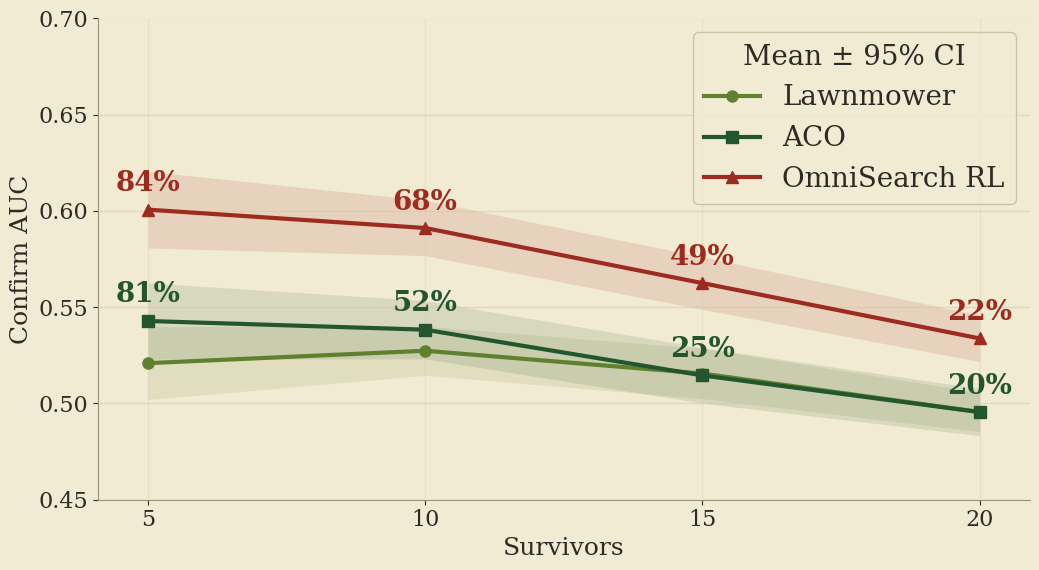

In [7]:
plot_df = metrics.copy()
if 'survivor_x' not in plot_df.columns:
    plot_df['survivor_x'] = plot_df.get('active_survivors_mean', float('nan'))
plot_df['survivor_x'] = pd.to_numeric(plot_df['survivor_x'], errors='coerce')
has_survivor_x = plot_df['survivor_x'].notna().all() and plot_df['survivor_x'].nunique() > 1


if has_survivor_x:
    fig, ax = plt.subplots(figsize=(12.8, 5.8), facecolor=plot.PAPER_BG)
    plot._plot_confirm_auc_curve(ax, plot_df, x_label='survivor_x', print_percentage=['happo','ant_colony'], title='Confirm AUC vs Surivors', x_title='Survivors', y_limit=[0.45,0.7])
else:
    plot_df = plot_df.reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(max(15, len(plot_df) * 2.1), 6.3), facecolor=plot.PAPER_BG)
    plot._plot_metrics_bars(
        ax,
        plot_df,
        plot.AUC_METRIC_SPECS,
        title=f'Success And Time-Integrated Performance (AUC) for {plot_df["survivor_x"].unique()[0]} survivors',
        ylabel='Score',
        y_limit=(0.0, 1.35),
        label_digits=3,
        x_labels='strategy',
    )

fig.tight_layout(rect=(0.0, 0.0, 0.82, 1.0) if has_survivor_x else None)
plt.savefig("../outputs/figures/survivor_load.png")
plt.show()
